# Affine Transformation via Matrix Application
# Segment 2: Eigendecomposition
# Affine Transformation via Matrix Application

In [1]:
import numpy as np
import tensorflow as tf
import torch
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# lets say we have a vector v:
v = np.array([3,1])
v

array([3, 1])

Let's plot $v$ using my `plot_vectors()` function (which is based on Hadrien Jean's `plotVectors()` function from [this notebook](this notebook), under [MIT license](MIT license)).

In [3]:
def plot_vectors(vectors, colors):
    """
    Plot one or more vectors in a 2D plane, specifying a color for each. 

    Arguments
    ---------
    vectors: list of lists or of arrays
        Coordinates of the vectors to plot. For example, [[1, 3], [2, 2]] 
        contains two vectors to plot, [1, 3] and [2, 2].
    colors: list
        Colors of the vectors. For instance: ['red', 'blue'] will display the
        first vector in red and the second in blue.
        
    Example
    -------
    plot_vectors([[1, 3], [2, 2]], ['red', 'blue'])
    plt.xlim(-1, 4)
    plt.ylim(-1, 4)
    """
    plt.figure()
    plt.axvline(x = 0, color = "lightgray")
    plt.axhline(y = 0, color = "lightgray")

    for i in range(len(vectors)):
        x = np.concatenate([[0,0], vectors[i]])
        plt.quiver([x[0]], [x[1]], [x[2]], [x[3]],
                   angles='xy', scale_units='xy', scale=1, color=colors[i],)
        print(vectors[i])
        print(x)

[3 1]
[0 0 3 1]


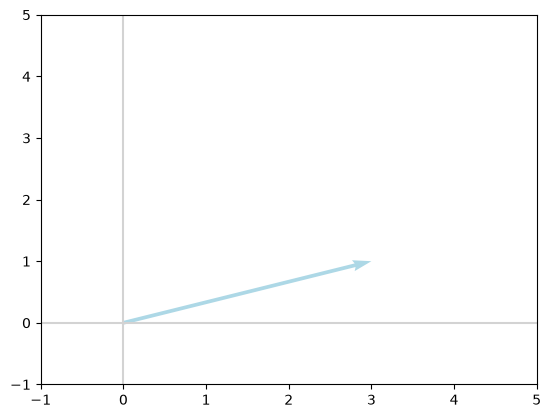

In [4]:
plot_vectors([v], ['lightblue'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

"Applying" a matrix to a vector (i.e., performing matrix-vector multiplication) can linearly transform the vector, e.g, rotate it or rescale it.

The identity matrix, introduced earlier, is the exception that proves the rule: Applying an identity matrix does not transform the vector:

In [5]:
I = np.array([[1,0],
             [0,1]])
I

array([[1, 0],
       [0, 1]])

In [6]:
v

array([3, 1])

In [7]:
Iv = np.dot(I,v)
Iv

array([3, 1])

In [8]:
v == Iv

array([ True,  True])

[3 1]
[0 0 3 1]


(-1.0, 5.0)

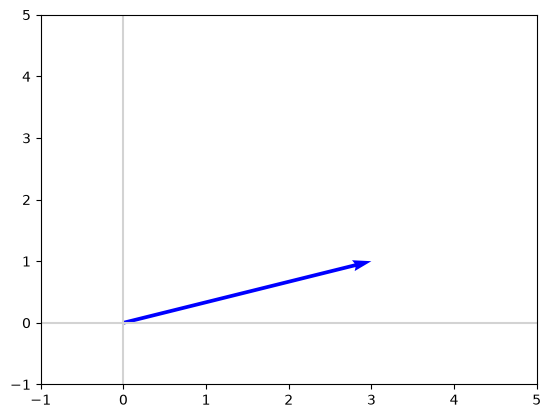

In [9]:
plot_vectors([Iv], ["blue"])
plt.xlim(-1,5)
plt.ylim(-1,5)

In contrast, consider this matrix (let's call it E) that flips vectors over the x-axis:

In [10]:
E = np.array([[1,0],
             [0,-1]])
E

array([[ 1,  0],
       [ 0, -1]])

In [11]:
v

array([3, 1])

In [12]:
Ev = np.dot(E,v)
Ev

array([ 3, -1])

[3 1]
[0 0 3 1]
[ 3 -1]
[ 0  0  3 -1]


(-3.0, 3.0)

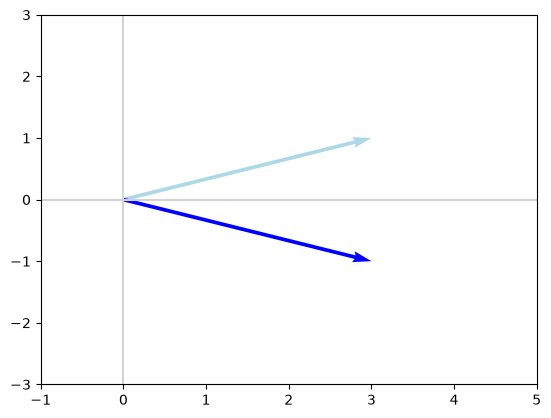

In [13]:
plot_vectors([v, Ev], ['lightblue', 'blue'])
plt.xlim(-1, 5)
plt.ylim(-3, 3)

Or, this matrix, F, which flips vectors over the y-axis:

In [14]:
F = np.array([[-1,0], [0,1]])
F

array([[-1,  0],
       [ 0,  1]])

In [15]:
v

array([3, 1])

In [16]:
Fv = np.dot(F,v)
Fv

array([-3,  1])

[3 1]
[0 0 3 1]
[-3  1]
[ 0  0 -3  1]


(-3.0, 5.0)

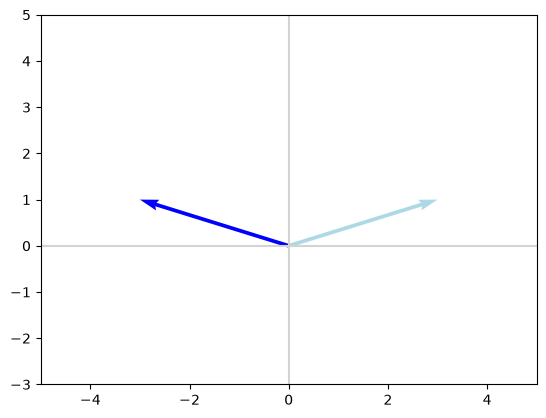

In [17]:
plot_vectors([v, Fv], ['lightblue', 'blue'])
plt.xlim(-5,5)
plt.ylim(-3,5)

Applying a flipping matrix is an example of an **affine transformation**: a change in geometry that may adjust distances or angles between vectors, but preserves parallelism between them.

In addition to flipping a matrix over an axis (a.k.a., *reflection*), other common affine transformations include:

* *Scaling* (changing the length of vectors)
* *Shearing* (example of this on the Mona Lisa coming up shortly)
* *Rotation*

(See [here](https://stackabuse.com/affine-image-transformations-in-python-with-numpy-pillow-and-opencv/) for an outstanding blog post on affine transformations in Python, including how to apply them to images as well as vectors.)

A single matrix can apply multiple affine transforms simultaneously (e.g., flip over an axis and rotate 45 degrees). As an example, let's see what happens when we apply this matrix $A$ to the vector $v$:

In [18]:
A = np.array([[-1,4],
             [2,-2]])
A

array([[-1,  4],
       [ 2, -2]])

In [19]:
v

array([3, 1])

In [20]:
Av = np.dot(A,v)
Av

array([1, 4])

[3 1]
[0 0 3 1]
[1 4]
[0 0 1 4]


(-1.0, 5.0)

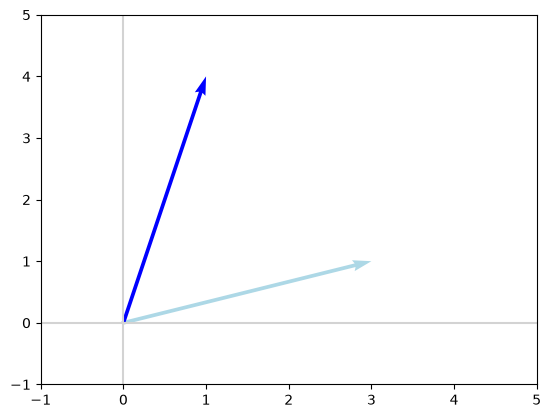

In [21]:
plot_vectors([v, Av], ["lightblue", "blue"])
plt.xlim(-1,5)
plt.ylim(-1,5)

[2 1]
[0 0 2 1]
[2 2]
[0 0 2 2]


(-1.0, 5.0)

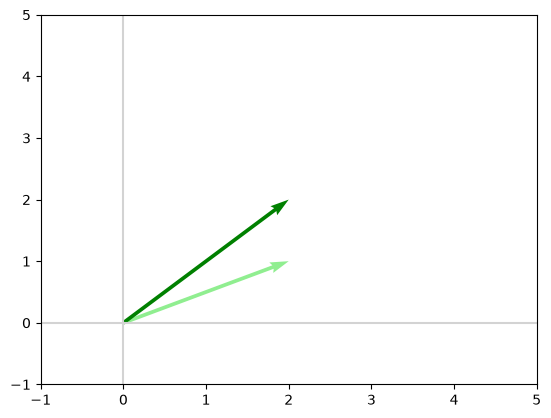

In [22]:
# Another example of  applying A:
v2 = np.array([2,1])
plot_vectors([v2,np.dot(A,v2)], ["lightgreen", "green"])
plt.xlim(-1,5)
plt.ylim(-1,5)

We can concatenate several vectors together into a matrix (say, $V$), where each column is a separate vector. Then, whatever linear transformations we apply to $V$ will be independently applied to each column (vector):

In [23]:
v

array([3, 1])

In [24]:
# recall that we need to convert array to 2D to transpose into column, e.g.:
np.matrix(v).T

matrix([[3],
        [1]])

In [25]:
v2

array([2, 1])

In [26]:
v3 = np.array([-3, -1]) # mirror image of v over both axes
v4 = np.array([-1, 1])

[3 1]
[0 0 3 1]
[-3 -1]
[ 0  0 -3 -1]


(-5.0, 5.0)

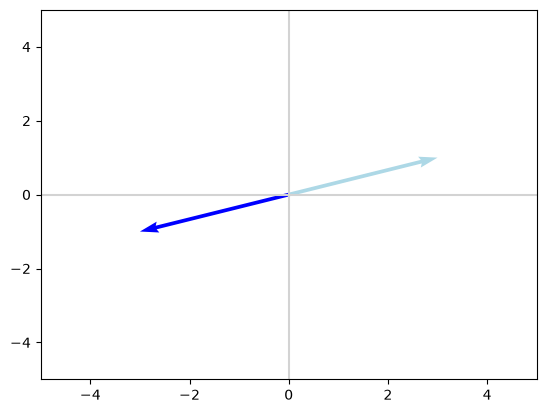

In [27]:
plot_vectors([v,v3], ["lightblue", "blue"])
plt.xlim(-5,5)
plt.ylim(-5,5)

In [54]:
V = np.concatenate((np.matrix(v).T,
                   np.matrix(v2).T,
                   np.matrix(v3).T,
                   np.matrix(v4).T), axis = 1)
V

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [55]:
# V = np.concatenate((np.matrix(v).T,
#                    np.matrix(v2).T,
#                    np.matrix(v3).T,
#                    np.matrix(v4).T), axis = 1)
# V

In [56]:
A

array([[-1,  4],
       [ 2, -2]])

In [57]:
I

array([[1, 0],
       [0, 1]])

In [58]:
I.shape

(2, 2)

In [59]:
A.shape

(2, 2)

In [60]:
V.shape

(2, 4)

In [61]:
IV = np.dot(I,V)
IV

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [62]:
AV = np.dot(A,V)
AV

matrix([[ 1,  2, -1,  5],
        [ 4,  2, -4, -4]])

In [63]:
# function to convert column of matrix to 1D vector: 
def vectorfy(mtrx, clmn):
    return np.array(mtrx[:,clmn]).reshape(-1)

In [64]:
V

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [65]:
vectorfy(V,0)


array([3, 1])

In [66]:
vectorfy(V, 0) == v

array([ True,  True])

[3 1]
[0 0 3 1]
[2 1]
[0 0 2 1]
[-3 -1]
[ 0  0 -3 -1]
[-1  1]
[ 0  0 -1  1]
[1 4]
[0 0 1 4]
[2 2]
[0 0 2 2]
[-1 -4]
[ 0  0 -1 -4]
[ 5 -4]
[ 0  0  5 -4]


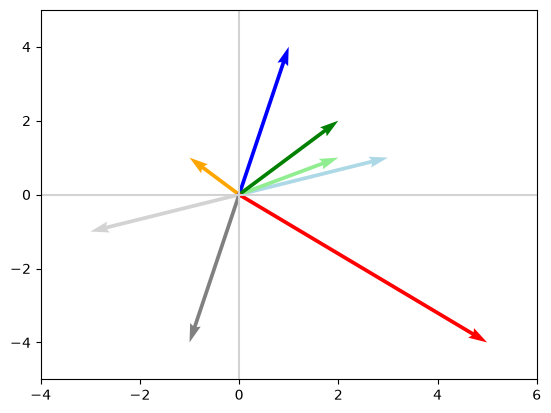

In [67]:
plot_vectors([vectorfy(V, 0), vectorfy(V, 1), vectorfy(V, 2), vectorfy(V, 3),
             vectorfy(AV, 0), vectorfy(AV, 1), vectorfy(AV, 2), vectorfy(AV, 3)], 
            ['lightblue', 'lightgreen', 'lightgray', 'orange',
             'blue', 'green', 'gray', 'red'])
plt.xlim(-4, 6)
_ = plt.ylim(-5, 5)

### Eigenvectors and Eigenvalues

An **eigenvector** (*eigen* is German for "typical"; we could translate *eigenvector* to "characteristic vector") is a special vector $v$ such that when it is transformed by some matrix (let's say $A$), the product $Av$ has the exact same direction as $v$.[cite: 5]

An **eigenvalue** is a scalar (traditionally represented as $\lambda$) that simply scales the eigenvector $v$ such that the following equation is satisfied:[cite: 5]

$$Av = \lambda v$$

Easiest way to understand this is to work through an example:[cite: 5]



In [73]:
A

array([[-1,  4],
       [ 2, -2]])

Eigenvectors and eigenvalues can be derived algebraically (e.g., with the (QR algorithm), which was independently developed in the 1950s by both (Vera Kublanovskaya) and John Francis), however this is outside scope of the *ML Foundations* series. We'll cheat with NumPy `eig()` method, which returns a tuple of:

* a vector of eigenvalues
* a matrix of eigenvectors



In [74]:
lambdas, V = np.linalg.eig(A)

The matrix contains as many eigenvectors as there are columns of A:

In [76]:
V= V.real
V

array([[ 0.86011126, -0.76454754],
       [ 0.51010647,  0.64456735]])

With a corresponding eigenvalue for each eigenvector:

In [72]:
lambdas

array([ 1.37228132+0.j, -4.37228132+0.j])

Let's confirm that $Av = \lambda v$ for the first eigenvector:

In [80]:
v = V[:,0]
v

array([0.86011126, 0.51010647])

In [88]:
lambduh = np.real(lambdas[0])
float(lambduh)

1.3722813232690143

In [93]:
A

array([[-1,  4],
       [ 2, -2]])

In [90]:
Av = np.dot(A,v)
Av

array([1.18031462, 0.70000958])

In [92]:
lambduh * v

array([1.18031462, 0.70000958])

[1.18031462 0.70000958]
[0.         0.         1.18031462 0.70000958]
[0.86011126 0.51010647]
[0.         0.         0.86011126 0.51010647]


(-1.0, 2.0)

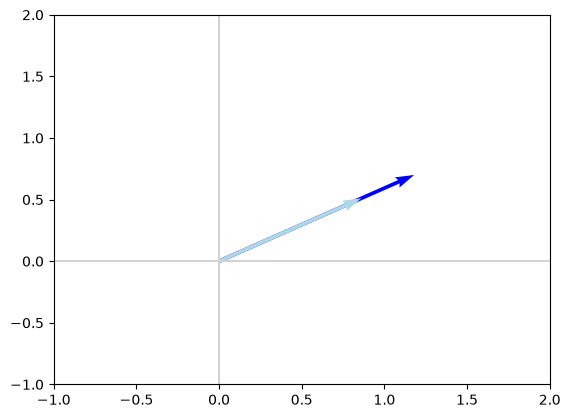

In [94]:
plot_vectors([Av,v], ["blue", "lightblue"])
plt.xlim(-1,2)
plt.ylim(-1,2)

And again for the second eigenvector of A:

In [95]:
v2 = V[:,1]
v2

array([-0.76454754,  0.64456735])

Av = lambda v

In [97]:
Av2 = np.dot(A,v2)
Av2

array([ 3.34281692, -2.81822977])

In [106]:
lamduh_2 = lambdas[1]
float(lamduh_2.real)

-4.372281323269014

In [102]:
np.real(lamduh_2*v2)

array([ 3.34281692, -2.81822977])

[1.18031462 0.70000958]
[0.         0.         1.18031462 0.70000958]
[0.86011126 0.51010647]
[0.         0.         0.86011126 0.51010647]
[ 3.34281692 -2.81822977]
[ 0.          0.          3.34281692 -2.81822977]
[-0.76454754  0.64456735]
[ 0.          0.         -0.76454754  0.64456735]


(-3.0, 2.0)

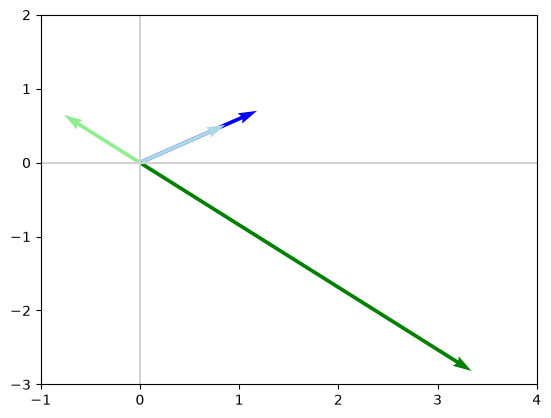

In [104]:
plot_vectors([Av, v, Av2, v2],
            ["blue", "lightblue", "green", "lightgreen"])
plt.xlim(-1, 4)
plt.ylim(-3, 2)

Using the PyTorch eig() method, we can do exactly the same:

In [108]:
A

array([[-1,  4],
       [ 2, -2]])

In [109]:
A_p = torch.tensor([[-1,4],
                   [2,-2]])
A_p

tensor([[-1,  4],
        [ 2, -2]])

In [110]:
lambdas_cplx, V_cplx = torch.linalg.eig(A_p)

RuntimeError: Unknown Complex ScalarType for Long